#Pain VS No Pain

We will be applying transfer learning to a pretrained Audio Spectrogram Transformer.

Hugging Face Model:
MIT/ast-finetuned-audioset-10-10-0.4593

The goal is for this model to correctly identify if the given spectrogram


# Model Configuration
Drop out layers and Early Stopping were added to the model in order to prevent the model from overfitting and memorizing data during training

In [1]:
!pip install -U transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 50.6 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [2]:
# Audio Classification Model
#Trained Hugging face Model: ast-finetuned-audioset-10-10-0.4593.ipynb

from transformers import pipeline
pipe = pipeline("audio-classification", model="MIT/ast-finetuned-audioset-10-10-0.4593")

# Load model directly
from transformers import AutoFeatureExtractor, AutoModelForAudioClassification, Trainer

extractor = AutoFeatureExtractor.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")
model = AutoModelForAudioClassification.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

In [3]:
# Data
from google.colab import drive
import os
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import torch
from torch.utils.data import Dataset

drive.mount('/content/gdrive')
pain = "/content/gdrive/MyDrive/ds340-project-data/Data/clean-pain-only/npy/pain"
no_pain = "/content/gdrive/MyDrive/ds340-project-data/Data/clean-pain-only/npy/no-pain"

Mounted at /content/gdrive


In [4]:
#Data Setup
import random
"""
We import random since there is more non-pain data than pain data.
We are going to randomly choose non-pain data samples until both
categories have the same number of samples
"""
# Make results reproducible
random.seed(42)

pain_files = [
    os.path.join(pain, f)
    for f in os.listdir(pain)
    if f.endswith(".npy")
]

no_pain_files = [
    os.path.join(no_pain, f)
    for f in os.listdir(no_pain)
    if f.endswith(".npy")
]

print("Original pain files:", len(pain_files))
print("Original no pain files:", len(no_pain_files))

# Downsample the non-pain class to match pain class
target_count = min(len(pain_files), len(no_pain_files))

pain_files = random.sample(pain_files, target_count)
no_pain_files = random.sample(no_pain_files, target_count)

print("Balanced pain files:", len(pain_files))
print("Balanced no pain files:", len(no_pain_files))

all_files = pain_files + no_pain_files
all_labels = [1] * len(pain_files) + [0] * len(no_pain_files)

Original pain files: 715
Original no pain files: 1386
Balanced pain files: 715
Balanced no pain files: 715


In [ ]:
# 2. LABELS
from transformers import ASTForAudioClassification, TrainingArguments, EarlyStoppingCallback, TrainerCallback
import random

id2label = {0: "no_pain", 1: "pain"}
label2id = {"no_pain": 0, "pain": 1}


# 3. LOAD MODEL WITH ARGUMENTS

model = ASTForAudioClassification.from_pretrained(
    "MIT/ast-finetuned-audioset-10-10-0.4593",
    num_labels=2,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
    hidden_dropout_prob=0.3,
    attention_probs_dropout_prob=0.3
)

TARGET_LENGTH = model.config.max_length
NUM_MEL_BINS = model.config.num_mel_bins

print("AST target_length:", TARGET_LENGTH)
print("AST num_mel_bins:", NUM_MEL_BINS)


# 4. LOAD FILE PATHS

pain_files = [
    os.path.join(pain, f)
    for f in os.listdir(pain)
    if f.endswith(".npy")
]

no_pain_files = [
    os.path.join(no_pain, f)
    for f in os.listdir(no_pain)
    if f.endswith(".npy")
]

print("Original pain files:", len(pain_files))
print("Original no pain files:", len(no_pain_files))

# balance classes
random.seed(42)
target_count = min(len(pain_files), len(no_pain_files))
pain_files = random.sample(pain_files, target_count)
no_pain_files = random.sample(no_pain_files, target_count)

all_files = pain_files + no_pain_files
all_labels = [1] * len(pain_files) + [0] * len(no_pain_files)

# filter out empty / corrupted / invalid npy files BEFORE splitting
def is_valid_npy_file(file_path, num_mel_bins):
    try:
        spec = np.load(file_path).astype(np.float32)

        if spec.ndim != 2:
            return False

        # allow either (time, mel) or (mel, time)
        if spec.shape[1] == num_mel_bins:
            return True
        if spec.shape[0] == num_mel_bins:
            return True

        return False
    except Exception:
        return False

good_files = []
good_labels = []
bad_files = []

for file_path, label in zip(all_files, all_labels):
    if is_valid_npy_file(file_path, NUM_MEL_BINS):
        good_files.append(file_path)
        good_labels.append(label)
    else:
        bad_files.append(file_path)

all_files = good_files
all_labels = good_labels

print("Usable files after filtering:", len(all_files))
print("Bad files removed:", len(bad_files))

if len(bad_files) > 0:
    print("First few bad files:")
    for f in bad_files[:20]:
        print(f)

if len(all_files) > 0:
    print("Raw sample shape:", np.load(all_files[0]).shape)


# 5. TRAIN / VALIDATION SPLIT

train_files, val_files, train_labels, val_labels = train_test_split(
    all_files,
    all_labels,
    test_size=0.2,
    random_state=42,
    stratify=all_labels
)


# 6. DATASET

class PainSpectrogramDataset(Dataset):
    def __init__(self, file_paths, labels, target_length, num_mel_bins):
        self.file_paths = file_paths
        self.labels = labels
        self.target_length = target_length
        self.num_mel_bins = num_mel_bins

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        file_path = self.file_paths[idx]

        try:
            spec = np.load(file_path).astype(np.float32)
        except Exception as e:
            raise ValueError(f"Could not load file {file_path}: {e}")

        if spec.ndim != 2:
            raise ValueError(f"Expected 2D spectrogram, got shape {spec.shape} for {file_path}")

        if spec.shape[0] == self.num_mel_bins and spec.shape[1] != self.num_mel_bins:
            spec = spec.T

        if spec.shape[1] != self.num_mel_bins:
            raise ValueError(
                f"Expected spectrogram with {self.num_mel_bins} mel bins, got shape {spec.shape} for {file_path}"
            )

        time_steps = spec.shape[0]

        if time_steps > self.target_length:
            spec = spec[:self.target_length, :]
        elif time_steps < self.target_length:
            pad_amount = self.target_length - time_steps
            spec = np.pad(spec, ((0, pad_amount), (0, 0)), mode="constant")

        mean = spec.mean()
        std = spec.std() + 1e-6
        spec = (spec - mean) / std

        return {
            "input_values": torch.tensor(spec, dtype=torch.float32),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = PainSpectrogramDataset(
    train_files,
    train_labels,
    target_length=TARGET_LENGTH,
    num_mel_bins=NUM_MEL_BINS
)

val_dataset = PainSpectrogramDataset(
    val_files,
    val_labels,
    target_length=TARGET_LENGTH,
    num_mel_bins=NUM_MEL_BINS
)


# 7. METRICS

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="binary",
        zero_division=0
    )
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }


# 8. TRAINING ARGUMENTS

training_args = TrainingArguments(
    output_dir="./ast_pain_binary",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=100,
    learning_rate=2e-6,
    weight_decay=1e-3,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=2,
    report_to="none",
    remove_unused_columns=False
)


# 9. CALLBACK TO LOG TRAIN METRICS EACH EPOCH

class TrainSetMetricsCallback(TrainerCallback):
    def __init__(self):
        self.trainer = None
        self._running = False

    def on_evaluate(self, args, state, control, **kwargs):
        if self.trainer is None or self._running:
            return

        self._running = True
        self.trainer.evaluate(
            eval_dataset=self.trainer.train_dataset,
            metric_key_prefix="train"
        )
        self._running = False

train_metrics_callback = TrainSetMetricsCallback()


# 10. TRAINER

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(early_stopping_patience=2),
        train_metrics_callback
    ]
)

train_metrics_callback.trainer = trainer


# 11. TRAIN / SAVE
train_output = trainer.train()

print("Training finished.")
print("Train metrics:", train_output.metrics)

val_logs = [entry for entry in trainer.state.log_history if "eval_loss" in entry]
train_logs = [entry for entry in trainer.state.log_history if "train_loss" in entry and "train_accuracy" in entry]

if len(val_logs) > 0:
    print("Final validation metrics:", val_logs[-1])
else:
    print("No validation metrics were found in log_history.")

if len(train_logs) > 0:
    print("Final training-set metrics:", train_logs[-1])
else:
    print("No training-set metrics were found in log_history.")

trainer.save_model("./ast_pain_binary_best")

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `527`.


Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

[transformers] ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                         
------------------------+----------+-----------------------------------------------------------------------------------------
classifier.dense.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([527, 768]) vs model:torch.Size([2, 768])
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([527]) vs model:torch.Size([2])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


AST target_length: 1024
AST num_mel_bins: 128
Original pain files: 715
Original no pain files: 1386
Usable files after filtering: 1429
Bad files removed: 1
First few bad files:
/content/gdrive/MyDrive/ds340-project-data/Data/clean-pain-only/npy/pain/03-02-11-01-01-72-02-02-02-11 - Copy.npy
Raw sample shape: (128, 94)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.750932,0.738055,0.541958,0.657895,0.174825,0.276243
2,0.714035,0.684863,0.569930,0.685185,0.258741,0.375635
3,0.694483,0.667213,0.576923,0.892857,0.174825,0.292398
4,0.646906,0.594328,0.674825,0.777778,0.489510,0.600858
5,0.617971,0.572015,0.702797,0.750000,0.608392,0.671815
6,0.577002,0.659837,0.716783,0.844444,0.531469,0.652361
7,0.567188,0.618082,0.716783,0.798077,0.580420,0.672065
8,0.541401,0.735473,0.713287,0.858824,0.510490,0.640351
9,0.535854,0.590168,0.737762,0.820755,0.608392,0.698795
10,0.511546,0.614597,0.737762,0.846939,0.580420,0.688797


...

[transformers] early stopping required metric_for_best_model, but did not find eval_f1 so early stopping is disabled


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] early stopping required metric_for_best_model, but did not find eval_f1 so early stopping is disabled


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.750932,0.738055,0.541958,0.657895,0.174825,0.276243
2,0.714035,0.684863,0.569930,0.685185,0.258741,0.375635
3,0.694483,0.667213,0.576923,0.892857,0.174825,0.292398
4,0.646906,0.594328,0.674825,0.777778,0.489510,0.600858
5,0.617971,0.572015,0.702797,0.750000,0.608392,0.671815
6,0.577002,0.659837,0.716783,0.844444,0.531469,0.652361
7,0.567188,0.618082,0.716783,0.798077,0.580420,0.672065
8,0.541401,0.735473,0.713287,0.858824,0.510490,0.640351
9,0.535854,0.590168,0.737762,0.820755,0.608392,0.698795
10,0.511546,0.614597,0.737762,0.846939,0.580420,0.688797


In [8]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

train_epochs = []
train_loss = []
train_accuracy = []
train_precision = []
train_recall = []
train_f1 = []

eval_epochs = []
eval_loss = []
eval_accuracy = []
eval_precision = []
eval_recall = []
eval_f1 = []

for entry in log_history:
    if "train_loss" in entry and "train_accuracy" in entry and "epoch" in entry:
        train_epochs.append(entry["epoch"])
        train_loss.append(entry.get("train_loss"))
        train_accuracy.append(entry.get("train_accuracy"))
        train_precision.append(entry.get("train_precision"))
        train_recall.append(entry.get("train_recall"))
        train_f1.append(entry.get("train_f1"))

    if "eval_loss" in entry and "epoch" in entry:
        eval_epochs.append(entry["epoch"])
        eval_loss.append(entry.get("eval_loss"))
        eval_accuracy.append(entry.get("eval_accuracy"))
        eval_precision.append(entry.get("eval_precision"))
        eval_recall.append(entry.get("eval_recall"))
        eval_f1.append(entry.get("eval_f1"))



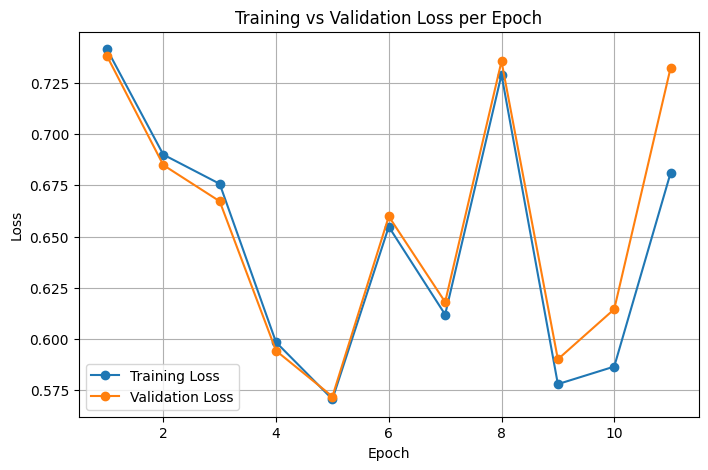

In [9]:
# 1. Training vs Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(train_epochs, train_loss, marker="o", label="Training Loss")
plt.plot(eval_epochs, eval_loss, marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss per Epoch")
plt.legend()
plt.grid(True)
plt.show()

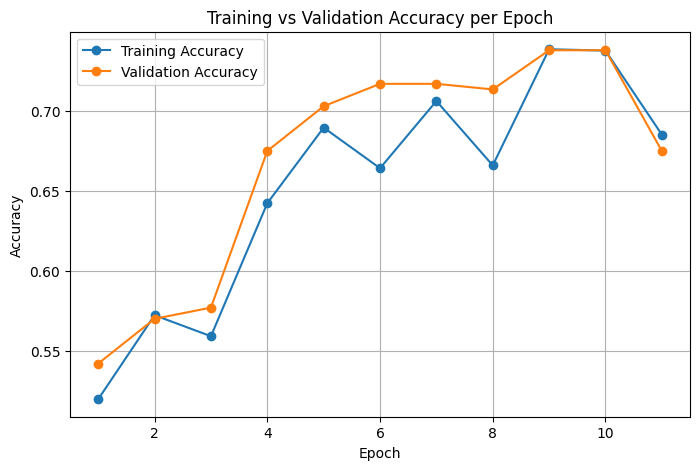

In [10]:
# 2. Training vs Validation Accuracy
plt.figure(figsize=(8, 5))
plt.plot(train_epochs, train_accuracy, marker="o", label="Training Accuracy")
plt.plot(eval_epochs, eval_accuracy, marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy per Epoch")
plt.legend()
plt.grid(True)
plt.show()

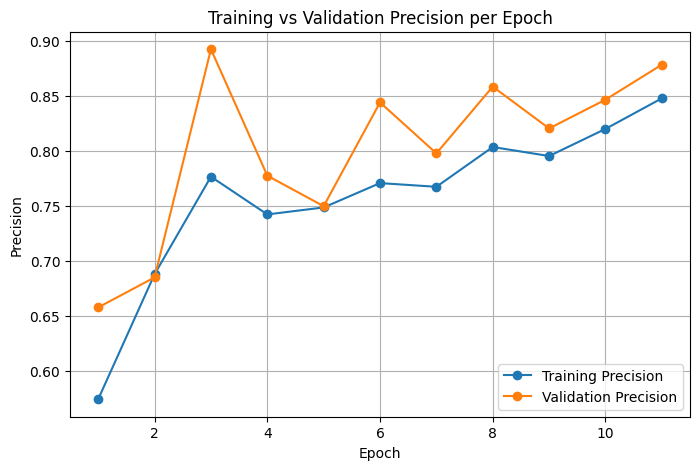

In [11]:
# 3. Training vs Validation Precision
plt.figure(figsize=(8, 5))
plt.plot(train_epochs, train_precision, marker="o", label="Training Precision")
plt.plot(eval_epochs, eval_precision, marker="o", label="Validation Precision")
plt.xlabel("Epoch")
plt.ylabel("Precision")
plt.title("Training vs Validation Precision per Epoch")
plt.legend()
plt.grid(True)
plt.show()

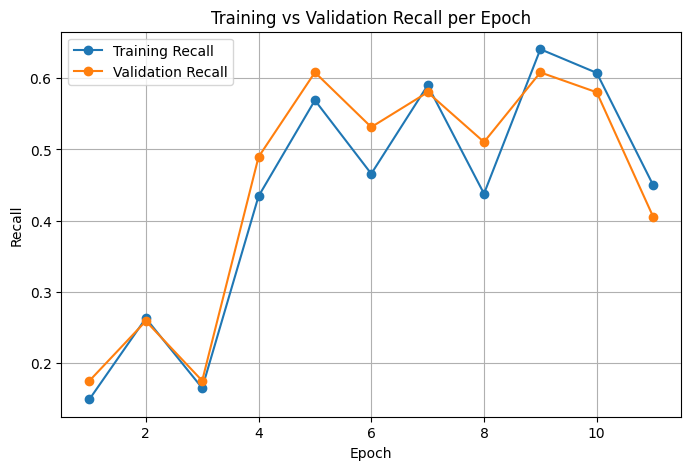

In [12]:
# 4. Training vs Validation Recall
plt.figure(figsize=(8, 5))
plt.plot(train_epochs, train_recall, marker="o", label="Training Recall")
plt.plot(eval_epochs, eval_recall, marker="o", label="Validation Recall")
plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.title("Training vs Validation Recall per Epoch")
plt.legend()
plt.grid(True)
plt.show()

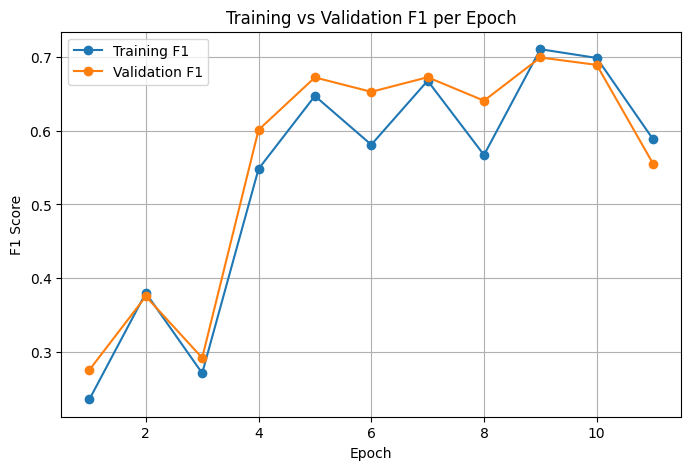

In [13]:
# 5. Training vs Validation F1
plt.figure(figsize=(8, 5))
plt.plot(train_epochs, train_f1, marker="o", label="Training F1")
plt.plot(eval_epochs, eval_f1, marker="o", label="Validation F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("Training vs Validation F1 per Epoch")
plt.legend()
plt.grid(True)
plt.show()

# Custom Example Testing

In [16]:
# 12. SINGLE SPECTROGRAM INFERENCE FOR BINARY PAIN / NO-PAIN MODEL

import torch
import numpy as np
import matplotlib.pyplot as plt

def predict_single_spectrogram(file_path, model, target_length, num_mel_bins, threshold=0.5):
    model.eval()

    device = next(model.parameters()).device

    spec = np.load(file_path).astype(np.float32)
    original_shape = spec.shape

    print("Original shape:", original_shape)

    if spec.ndim != 2:
        raise ValueError(f"Expected 2D spectrogram, got shape {spec.shape} for {file_path}")

    # If saved as (mel, time), transpose to (time, mel)
    if spec.shape[0] == num_mel_bins and spec.shape[1] != num_mel_bins:
        spec = spec.T

    if spec.shape[1] != num_mel_bins:
        raise ValueError(
            f"Expected spectrogram with {num_mel_bins} mel bins, got shape {spec.shape} for {file_path}"
        )

    # Show original unpadded / uncropped spectrogram
    display_spec = spec.copy()

    plt.figure(figsize=(10, 4))
    plt.imshow(display_spec.T, aspect="auto", origin="lower")
    plt.xlabel("Time")
    plt.ylabel("Mel Bin")
    plt.title("Original Spectrogram Being Judged")
    plt.colorbar()
    plt.show()

    # Crop or pad time dimension for model input
    time_steps = spec.shape[0]

    if time_steps > target_length:
        spec = spec[:target_length, :]
    elif time_steps < target_length:
        pad_amount = target_length - time_steps
        spec = np.pad(spec, ((0, pad_amount), (0, 0)), mode="constant")

    # Normalize
    mean = spec.mean()
    std = spec.std() + 1e-6
    spec = (spec - mean) / std

    processed_shape = spec.shape

    # Add batch dimension and move to same device as model
    input_tensor = torch.tensor(spec, dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_values=input_tensor)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=1).detach().cpu().numpy()[0]

    no_pain_prob = float(probs[0])
    pain_prob = float(probs[1])

    prediction = "pain" if pain_prob >= threshold else "no_pain"

    print("Processed shape:", processed_shape)
    print("Prediction:", prediction)
    print("Probability for pain:", round(pain_prob, 6))
    print("Probability for no pain:", round(no_pain_prob, 6))
    print("Threshold:", threshold)

    # Horizontal bar chart of binary probabilities
    class_names = ["pain", "no_pain"]
    class_probs = [pain_prob, no_pain_prob]

    plt.figure(figsize=(8, 3))
    plt.barh(class_names, class_probs)
    plt.xlabel("Probability")
    plt.ylabel("Class")
    plt.title("Binary Model Probabilities")
    plt.xlim(0, 1)
    plt.gca().invert_yaxis()
    plt.show()

    return {
        "original_shape": tuple(original_shape),
        "processed_shape": tuple(processed_shape),
        "prediction": prediction,
        "pain_probability": pain_prob,
        "no_pain_probability": no_pain_prob,
        "threshold": threshold
    }

Original shape: (128, 94)


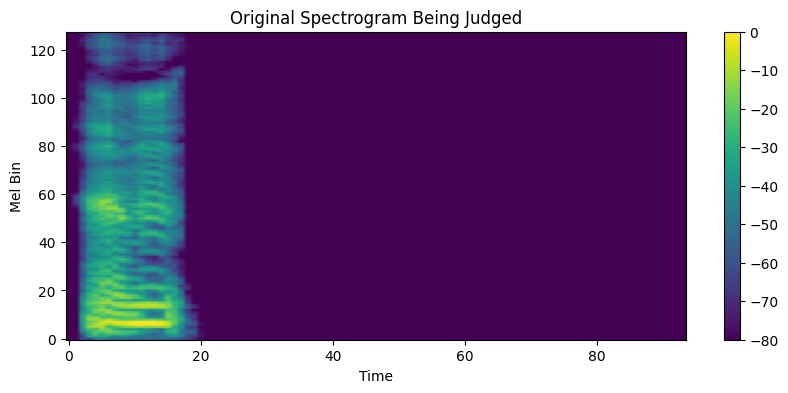

Processed shape: (1024, 128)
Prediction: pain
Probability for pain: 0.547089
Probability for no pain: 0.452911
Threshold: 0.5


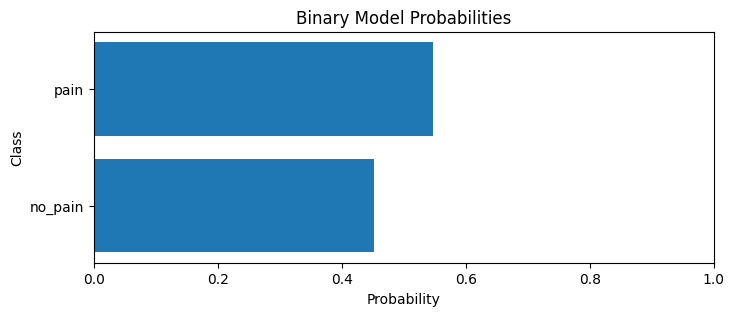

In [21]:
sample_file = val_files[20]

result = predict_single_spectrogram(
    file_path=sample_file,
    model=model,
    target_length=TARGET_LENGTH,
    num_mel_bins=NUM_MEL_BINS,
    threshold=0.5
)